In [1]:
from __future__ import annotations

import numpy as np
import stim

from qldpc import circuits, codes
from qldpc.objects import Pauli


class BellPairJointParitySyndrome(circuits.SyndromeMeasurementStrategy):
    """Measure CSS stabilizers using one Bell pair per stabilizer.

    For a Z-check:
        prepare Bell pair a,b
        CNOT data -> a or b
        measure Z_a Z_b with MZZ

    For an X-check:
        prepare Bell pair a,b
        CNOT a or b -> data
        measure X_a X_b with MXX

    The single MZZ/MXX result is the stabilizer syndrome bit.
    """

    def __init__(self, *, split_support=None) -> None:
        # split_support(support) should return (left_support, right_support).
        # By default, split the stabilizer support roughly in half.
        self.split_support = split_support or self._default_split

    @staticmethod
    def _default_split(support: list[int]) -> tuple[list[int], list[int]]:
        midpoint = len(support) // 2
        return support[:midpoint], support[midpoint:]

    def get_circuit(
        self,
        code: codes.QuditCode,
        qubit_ids: circuits.QubitIDs | None = None,
    ) -> tuple[stim.Circuit, circuits.MeasurementRecord]:
        if not isinstance(code, codes.CSSCode):
            raise ValueError("This Bell-pair strategy assumes a CSS code.")

        # We need one normal qLDPC check qubit plus one extra Bell-half ancilla per check.
        if qubit_ids is None:
            qubit_ids = circuits.QubitIDs.from_code(code, num_ancillas=code.num_checks)

        if len(qubit_ids.ancilla) < code.num_checks:
            raise ValueError(
                f"Need at least {code.num_checks} extra ancillas, one per check. "
                f"Got {len(qubit_ids.ancilla)}."
            )

        circuit = stim.Circuit()
        measurement_for_check: dict[int, int] = {}
        measurement_index = 0

        # qLDPC orders CSS checks as all X checks followed by all Z checks.
        check_specs = []

        for local_row, check_id in enumerate(qubit_ids.checks_x):
            row = np.asarray(code.matrix_x[local_row], dtype=np.uint8)
            check_specs.append((Pauli.X, row, check_id))

        for local_row, check_id in enumerate(qubit_ids.checks_z):
            row = np.asarray(code.matrix_z[local_row], dtype=np.uint8)
            check_specs.append((Pauli.Z, row, check_id))

        for global_check_index, (pauli, row, check_id) in enumerate(check_specs):
            a = check_id
            b = qubit_ids.ancilla[global_check_index]

            support = [
                qubit_ids.data[col]
                for col, value in enumerate(row)
                if int(value) % 2
            ]
            left_support, right_support = self.split_support(support)

            # Prepare |Phi+> on a,b.
            circuit.append("R", [a, b])
            circuit.append("H", [a])
            circuit.append("CX", [a, b])
            circuit.append("TICK")

            if pauli is Pauli.Z:
                # Write Z parity onto the Bell pair's ZZ parity.
                targets: list[int] = []
                for q in left_support:
                    targets += [q, a]  # CNOT data -> bell half
                for q in right_support:
                    targets += [q, b]
                if targets:
                    circuit.append("CX", targets)
                circuit.append("TICK")

                # Single syndrome bit.
                circuit.append("MZZ", [a, b])

            elif pauli is Pauli.X:
                # Write X parity onto the Bell pair's XX parity.
                targets = []
                for q in left_support:
                    targets += [a, q]  # CNOT bell half -> data
                for q in right_support:
                    targets += [b, q]
                if targets:
                    circuit.append("CX", targets)
                circuit.append("TICK")

                # Single syndrome bit.
                circuit.append("MXX", [a, b])

            else:
                raise NotImplementedError(pauli)

            measurement_for_check[check_id] = measurement_index
            measurement_index += 1
            circuit.append("TICK")

        return circuit, circuits.MeasurementRecord(measurement_for_check)

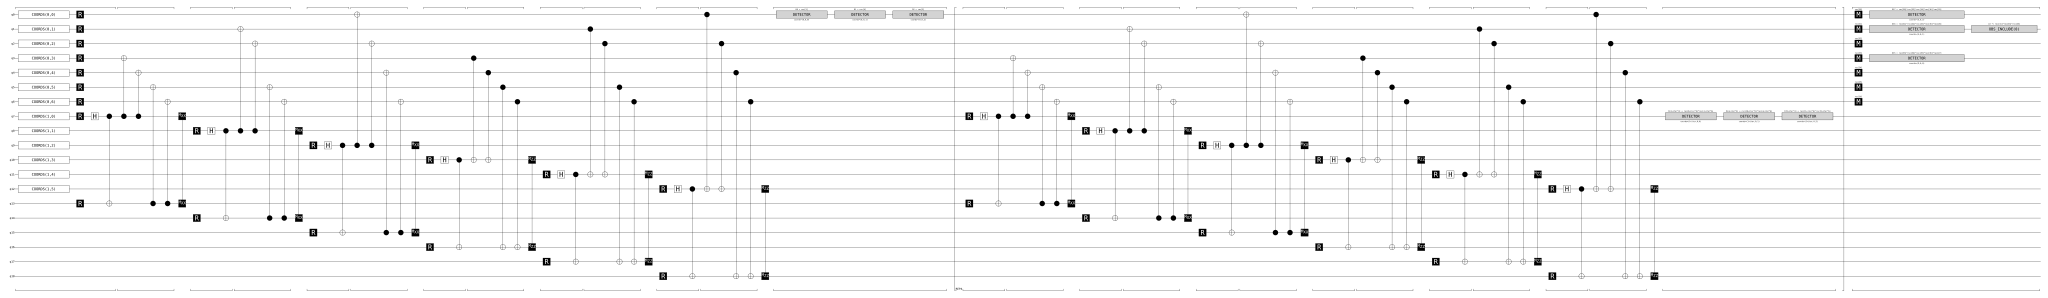

In [4]:
code = codes.SteaneCode()

# qLDPC's SteaneCode is the size-3 QuantumHammingCode. 
# It is a CSS code with 7 data qubits, 1 logical qubit, and distance 3.
# qLDPC provides it directly as codes.SteaneCode().
qubit_ids = circuits.QubitIDs.from_code(code, num_ancillas=code.num_checks)

strategy = BellPairJointParitySyndrome()

circuit = circuits.get_memory_experiment(
    code,
    basis=Pauli.Z,          # use Pauli.X to track X logical errors instead
    num_rounds=5,
    qubit_ids=qubit_ids,
    syndrome_measurement_strategy=strategy,
)
circuit.diagram("timeline-svg")

# print(circuit)
# sampler = circuit.compile_detector_sampler()
# dets, obs = sampler.sample(shots=1000, separate_observables=True)

In [1]:
from __future__ import annotations

import numpy as np
import stim

from qldpc import codes
from qldpc.objects import Pauli


def _reset_gate(basis: Pauli) -> str:
    return "RX" if basis is Pauli.X else "R"


def _measure_gate(basis: Pauli) -> str:
    return "MX" if basis is Pauli.X else "M"


def _rec(global_measurement_index: int, num_measurements_so_far: int) -> stim.GateTarget:
    """Convert an absolute measurement index into a Stim rec[-k] target."""
    return stim.target_rec(global_measurement_index - num_measurements_so_far)


def append_two_bit_bell_pair_check(
    circuit: stim.Circuit,
    *,
    row: np.ndarray,
    data_qubits: list[int],
    bell_left: int,
    bell_right: int,
    basis: Pauli,
    num_measurements_so_far: int,
) -> tuple[tuple[int, int], int]:
    """Append one Bell-pair stabilizer measurement.

    Returns:
        ((m_left, m_right), new_num_measurements_so_far)

    The stabilizer syndrome is m_left XOR m_right.
    """

    support = [
        data_qubits[col]
        for col, value in enumerate(row)
        if int(value) % 2
    ]

    # For the Steane code, each stabilizer has weight 4, so this makes a 2/2 split.
    midpoint = len(support) // 2
    left_support = support[:midpoint]
    right_support = support[midpoint:]

    # Prepare |Phi+> on the Bell pair.
    circuit.append("R", [bell_left, bell_right])
    circuit.append("H", [bell_left])
    circuit.append("CX", [bell_left, bell_right])
    circuit.append("TICK")

    if basis is Pauli.Z:
        # Measure product of Zs on data:
        # CNOT data -> Bell half, then measure Bell halves in Z.
        targets: list[int] = []
        for q in left_support:
            targets += [q, bell_left]
        for q in right_support:
            targets += [q, bell_right]
        if targets:
            circuit.append("CX", targets)
        circuit.append("TICK")

        m_left = num_measurements_so_far
        m_right = num_measurements_so_far + 1
        circuit.append("M", [bell_left, bell_right])
        num_measurements_so_far += 2

    elif basis is Pauli.X:
        # Measure product of Xs on data:
        # CNOT Bell half -> data, then measure Bell halves in X.
        targets = []
        for q in left_support:
            targets += [bell_left, q]
        for q in right_support:
            targets += [bell_right, q]
        if targets:
            circuit.append("CX", targets)
        circuit.append("TICK")

        m_left = num_measurements_so_far
        m_right = num_measurements_so_far + 1
        circuit.append("MX", [bell_left, bell_right])
        num_measurements_so_far += 2

    else:
        raise ValueError(f"Expected Pauli.X or Pauli.Z, got {basis!r}")

    circuit.append("TICK")
    return (m_left, m_right), num_measurements_so_far


def steane_bell_pair_memory_circuit(
    *,
    basis: Pauli = Pauli.Z,
    num_rounds: int = 5,
) -> stim.Circuit:
    """Build a fixed-basis Steane memory experiment using two-bit Bell-pair syndrome readout.

    For basis=Pauli.Z:
        initialize |0>^7,
        repeatedly measure Z stabilizers with Bell pairs,
        finally measure data in Z,
        annotate logical Z observable.

    For basis=Pauli.X:
        initialize |+>^7,
        repeatedly measure X stabilizers with Bell pairs,
        finally measure data in X,
        annotate logical X observable.
    """

    if basis not in (Pauli.X, Pauli.Z):
        raise ValueError("This fixed-basis example expects basis=Pauli.X or basis=Pauli.Z")

    code = codes.SteaneCode()
    H = np.asarray(code.get_matrix(basis), dtype=np.uint8)

    n = len(code)
    num_checks = H.shape[0]

    data = list(range(n))

    # Use one Bell pair per check, reused each round.
    # For Steane in one basis: 7 data + 2*3 Bell qubits = 13 total qubits.
    bell_left = [n + 2 * k for k in range(num_checks)]
    bell_right = [n + 2 * k + 1 for k in range(num_checks)]

    circuit = stim.Circuit()

    # Optional coordinates.
    for q in data:
        circuit.append("QUBIT_COORDS", q, (0, q))
    for k, q in enumerate(bell_left):
        circuit.append("QUBIT_COORDS", q, (1, k, 0))
    for k, q in enumerate(bell_right):
        circuit.append("QUBIT_COORDS", q, (1, k, 1))

    num_measurements = 0

    # Prepare the memory basis state.
    circuit.append(_reset_gate(basis), data)
    circuit.append("TICK")

    previous_round: list[tuple[int, int]] | None = None

    for round_index in range(num_rounds):
        current_round: list[tuple[int, int]] = []

        for check_index, row in enumerate(H):
            pair_measurements, num_measurements = append_two_bit_bell_pair_check(
                circuit,
                row=row,
                data_qubits=data,
                bell_left=bell_left[check_index],
                bell_right=bell_right[check_index],
                basis=basis,
                num_measurements_so_far=num_measurements,
            )
            current_round.append(pair_measurements)

        # Add syndrome detectors.
        if round_index == 0:
            # Initial state is a +1 eigenstate of all basis-type stabilizers,
            # so each Bell-pair syndrome parity should be 0.
            for check_index, (m0, m1) in enumerate(current_round):
                circuit.append(
                    "DETECTOR",
                    [
                        _rec(m0, num_measurements),
                        _rec(m1, num_measurements),
                    ],
                    (round_index, 0, check_index),
                )
        else:
            # Current syndrome parity should match previous syndrome parity.
            assert previous_round is not None
            for check_index, ((m0, m1), (p0, p1)) in enumerate(
                zip(current_round, previous_round)
            ):
                circuit.append(
                    "DETECTOR",
                    [
                        _rec(m0, num_measurements),
                        _rec(m1, num_measurements),
                        _rec(p0, num_measurements),
                        _rec(p1, num_measurements),
                    ],
                    (round_index, 0, check_index),
                )

        previous_round = current_round
        circuit.append("SHIFT_COORDS", [], (1, 0, 0))

    assert previous_round is not None

    # Final data readout.
    final_data_measurements = {
        q: num_measurements + j
        for j, q in enumerate(data)
    }
    circuit.append(_measure_gate(basis), data)
    num_measurements += len(data)

    # Final detectors: final data stabilizer parity should agree with last measured syndrome.
    for check_index, row in enumerate(H):
        data_targets = [
            _rec(final_data_measurements[data[col]], num_measurements)
            for col, value in enumerate(row)
            if int(value) % 2
        ]
        m0, m1 = previous_round[check_index]
        syndrome_targets = [
            _rec(m0, num_measurements),
            _rec(m1, num_measurements),
        ]

        circuit.append(
            "DETECTOR",
            data_targets + syndrome_targets,
            (num_rounds, 0, check_index),
        )

    # Logical observable annotation.
    # For Steane there is one logical operator in each basis.
    logicals = np.asarray(code.get_logical_ops(basis), dtype=np.uint8)
    for obs_index, logical in enumerate(logicals):
        obs_targets = [
            _rec(final_data_measurements[data[col]], num_measurements)
            for col, value in enumerate(logical)
            if int(value) % 2
        ]
        circuit.append("OBSERVABLE_INCLUDE", obs_targets, obs_index)

    return circuit

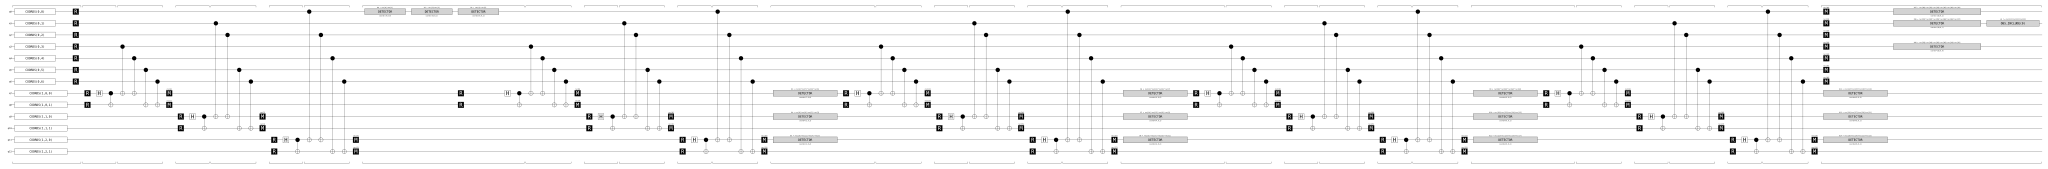

In [3]:
from qldpc.objects import Pauli

circuit = steane_bell_pair_memory_circuit(
    basis=Pauli.Z,
    num_rounds=5,
)
circuit.diagram("timeline-svg")

# print(circuit)

# # Sanity checks.
# print("num_detectors =", circuit.num_detectors)
# print("num_observables =", circuit.num_observables)

# # Sampling.
# sampler = circuit.compile_detector_sampler()
# detectors, observables = sampler.sample(
#     shots=1000,
#     separate_observables=True,
# )

In [1]:
from __future__ import annotations

from collections.abc import Callable, Sequence

import numpy as np
import stim

from qldpc import circuits, codes
from qldpc.objects import Pauli


SupportSplit = Callable[
    [list[int], int, Pauli],
    tuple[Sequence[int], Sequence[int]],
]


def balanced_split(
    support_cols: list[int],
    check_index: int,
    basis: Pauli,
) -> tuple[list[int], list[int]]:
    midpoint = len(support_cols) // 2
    return support_cols[:midpoint], support_cols[midpoint:]


class BellPairParitySyndrome(circuits.SyndromeMeasurementStrategy):
    """CSS syndrome extraction where each check syndrome is m_left XOR m_right."""

    def __init__(
        self,
        *,
        split_support: SupportSplit = balanced_split,
    ) -> None:
        self.split_support = split_support

    def get_circuit(
        self,
        code: codes.QuditCode,
        qubit_ids: circuits.QubitIDs | None = None,
    ) -> tuple[stim.Circuit, circuits.ParityMeasurementRecord]:
        if not isinstance(code, codes.CSSCode):
            raise ValueError("BellPairParitySyndrome currently supports CSS codes only.")

        qubit_ids = qubit_ids or circuits.QubitIDs.from_code(
            code,
            num_ancillas=code.num_checks,
        )

        if len(qubit_ids.ancilla) < code.num_checks:
            raise ValueError(
                f"Need at least {code.num_checks} ancilla qubits, one extra Bell half per check. "
                f"Got {len(qubit_ids.ancilla)}."
            )

        circuit = stim.Circuit()
        record: dict[int, tuple[int, int]] = {}
        num_measurements = 0

        check_specs: list[tuple[Pauli, np.ndarray, int]] = []

        # qLDPC orders CSS check qubits as X checks first, then Z checks.
        for local_row, check_id in enumerate(qubit_ids.checks_x):
            row = np.asarray(code.matrix_x[local_row], dtype=np.uint8) % 2
            check_specs.append((Pauli.X, row, check_id))

        for local_row, check_id in enumerate(qubit_ids.checks_z):
            row = np.asarray(code.matrix_z[local_row], dtype=np.uint8) % 2
            check_specs.append((Pauli.Z, row, check_id))

        for global_check_index, (basis, row, check_id) in enumerate(check_specs):
            bell_left = check_id
            bell_right = qubit_ids.ancilla[global_check_index]

            support_cols = [
                col
                for col, value in enumerate(row)
                if int(value) % 2
            ]

            left_cols, right_cols = self.split_support(
                support_cols,
                global_check_index,
                basis,
            )

            if set(left_cols) | set(right_cols) != set(support_cols):
                raise ValueError(
                    "split_support must cover the stabilizer support exactly."
                )

            if set(left_cols) & set(right_cols):
                raise ValueError(
                    "split_support must not put the same data qubit on both Bell halves."
                )

            # Prepare |Phi+> on the two Bell halves.
            circuit.append("RZ", [bell_left, bell_right])
            circuit.append("H", [bell_left])
            circuit.append("CX", [bell_left, bell_right])
            circuit.append("TICK")

            if basis is Pauli.Z:
                # Z-check:
                # CNOT data -> Bell half, then measure Bell halves in Z.
                targets: list[int] = []

                for col in left_cols:
                    targets += [qubit_ids.data[col], bell_left]

                for col in right_cols:
                    targets += [qubit_ids.data[col], bell_right]

                if targets:
                    circuit.append("CX", targets)

                circuit.append("TICK")

                m_left = num_measurements
                m_right = num_measurements + 1
                circuit.append("MZ", [bell_left, bell_right])
                num_measurements += 2

            elif basis is Pauli.X:
                # X-check:
                # CNOT Bell half -> data, then measure Bell halves in X.
                targets = []

                for col in left_cols:
                    targets += [bell_left, qubit_ids.data[col]]

                for col in right_cols:
                    targets += [bell_right, qubit_ids.data[col]]

                if targets:
                    circuit.append("CX", targets)

                circuit.append("TICK")

                m_left = num_measurements
                m_right = num_measurements + 1
                circuit.append("MX", [bell_left, bell_right])
                num_measurements += 2

            else:
                raise NotImplementedError(basis)

            # The effective syndrome bit is m_left XOR m_right.
            record[check_id] = (m_left, m_right)
            circuit.append("TICK")

        return circuit, circuits.ParityMeasurementRecord(
            record,
            num_events=num_measurements,
        )

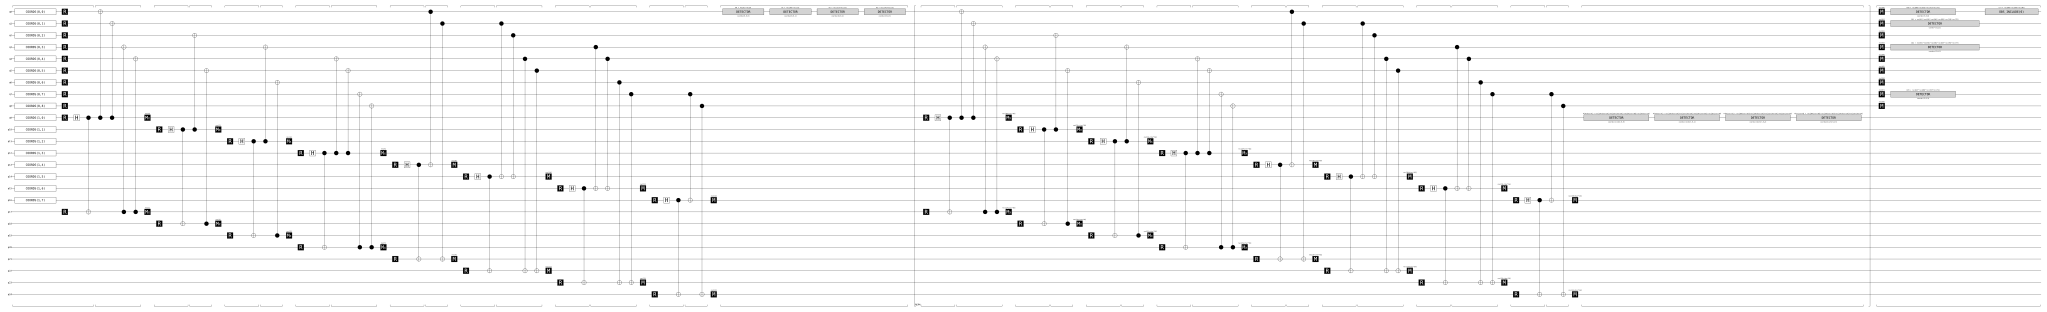

In [3]:
from qldpc import circuits, codes
from qldpc.objects import Pauli

code = codes.SurfaceCode(3)

qubit_ids = circuits.QubitIDs.from_code(
    code,
    num_ancillas=code.num_checks,
)

circuit = circuits.get_memory_experiment(
    code,
    basis=Pauli.Z,
    num_rounds=5,
    qubit_ids=qubit_ids,
    syndrome_measurement_strategy=circuits.BellPairParitySyndrome(),
)
circuit.diagram("timeline-svg")

# print(circuit)

# sampler = circuit.compile_detector_sampler()
# dets, obs = sampler.sample(shots=1000, separate_observables=True)